# 使用 PROC MDS 绘制移动运营商感知地图

## 执行摘要

一家电信市场研究团队衡量客户对八家竞争性移动运营商的感知相似程度，并使用 **PROC MDS** 从差异度矩阵中恢复出一张二维感知地图。两条潜在轴——网络质量与价格/性价比——被刻意构造为*相互独立*地变化，因此恢复出的地图确实是二维的：它展示了哪些品牌被视为可替代品、哪些品牌占据独特的定位，以及两个维度对竞争格局的概括程度。

## 数据来源

| 数据集 | 行数 | 关键变量 | 描述 |
|---------|------|---------------|-------------|
| `WORK.CARRIER_DISSIM` | 8（每家运营商一行） | `Carrier`（编号）、`D1`-`D8` | 8 家移动运营商之间感知差异度的方阵，采用 0-10 量表（0 = 感知完全相同，数值越高差异越大）。数据基于两条*独立*轴（网络质量与价格/性价比）上的潜在二维品牌定位，并通过 `rand('NORMAL')` 加入调查噪声生成。对角线为 0。 |

# 使用 PROC MDS 绘制移动运营商感知地图

电信行业的市场研究团队经常让调查小组评价竞争运营商之间感觉有多*相似*或*不同*。这些两两判断构成一个没有天然坐标系统的**邻近度矩阵**——但**多维尺度分析（MDS）**可以恢复出一个低维地图，其中两个品牌之间的距离能重现它们的感知差异度。

在本 notebook 中，我们将：

1. 基于两条*独立*的定位轴（网络质量与价格/性价比）合成一个真实的 8 家运营商差异度矩阵。
2. 使用 `PROC MDS` 拟合一个二维度量 MDS 模型。
3. 读取恢复出的坐标与拟合劣度，然后根据恢复出的坐标绘制感知地图，以判断两个维度对竞争格局的解释程度。

## 步骤 1 - 构建合成差异度矩阵

我们将每家运营商放置在两条**独立**轴上的*真实*潜在位置：

- **网络质量轴** - 高端全国性运营商得分高；廉价 MVNO（虚拟运营商）得分低。
- **价格/性价比轴** - 高性价比/预付费品牌得分高；高端定价品牌得分低。

关键在于，这两条轴在这八个品牌之间是不相关的：一家高质量的运营商既可以是高端定价（北极星），也可以是激进的高性价比定价（蓝峰）；而一家廉价质量的运营商在价格轴上可以处于任意位置。正是这种独立性，使得恢复出的地图真正呈现二维结构，而不会坍缩成一条直线。

两家运营商之间的感知差异度是它们潜在位置之间的欧氏距离，被重新缩放到 0-10 的调查量表，并加入对称的调查噪声。`PROC MDS` 需要一个**方阵**：每个对象一行，每个对象一个数值列，行的顺序与列的顺序一致。我们写入 `D1`-`D8` 列以及一个 `Carrier` 标签列，并强制矩阵对称、对角线为零。

In [1]:
数据 carrier_dissim;
    长度 Carrier $ 18;
    调用 streaminit(20240517);

    /* 两条独立轴上的真实二维潜在位置：
       qx = 网络质量，px = 价格/性价比（相关性 ~ 0）。 */
    数组 qx[8] _temporary_ (9.0 8.0 7.5 5.5 4.0 2.0 6.0 3.0);
    数组 px[8] _temporary_ (8.0 3.0 6.5 5.0 8.5 7.0 2.5 4.0);

    /* 对称噪声矩阵，只生成一次，对角线为零 */
    数组 e[8,8] _temporary_;
    循环 i = 1 到 8;
        e[i,i] = 0;
        循环 j = i+1 到 8;
            e[i,j] = rand('NORMAL', 0, 0.35);
            e[j,i] = e[i,j];
        结束;
    结束;

    数组 d[8] D1-D8;
    循环 i = 1 到 8;
        如果 i=1 那么 Carrier = "北极星";
        否则 如果 i=2 那么 Carrier = "蓝峰";
        否则 如果 i=3 那么 Carrier = "顶点";
        否则 如果 i=4 那么 Carrier = "都市通";
        否则 如果 i=5 那么 Carrier = "优值通";
        否则 如果 i=6 那么 Carrier = "省钱通";
        否则 如果 i=7 那么 Carrier = "中线通";
        否则 Carrier = "分毫通";
        循环 j = 1 到 8;
            DIST = sqrt( (qx[i]-qx[j])**2 + (px[i]-px[j])**2 );
            /* 将潜在距离重新缩放到 0-10 的调查量表 */
            d[j] = round( MAX(0, MIN(10, DIST*0.85 + e[i,j])), 0.1);
        结束;
        d[i] = 0;            /* 品牌与自身完全相同 */
        输出;
    结束;

    保留 Carrier D1-D8;
运行;

过程 打印 数据=carrier_dissim noobs 标签;
    标签 Carrier = '运营商';
    标题 '感知差异矩阵（0 = 完全相同，10 = 差异最大）';
运行;

                                               感知差异矩阵（0 = 完全相同，10 = 差异最大）                                               

      运营商   D1   D2   D3   D4   D5   D6   D7   D8
北极星          0  3.5  1.6  3.6  4.1  6.1  5.5  6.5
蓝峰         3.5    0  2.5  2.9  5.9    6    2    5
顶点         1.6  2.5    0  1.7  3.6  5.1  3.4    4
都市通        3.6  2.9  1.7    0  3.1  3.6  1.9    2
优值通        4.1  5.9  3.6  3.1    0  1.8  5.1  4.3
省钱通        6.1    6  5.1  3.6  1.8    0  5.3  2.3
中线通        5.5    2  3.4  1.9  5.1  5.3    0  2.5
分毫通        6.5    5    4    2  4.3  2.3  2.5    0




NOTE: DATA carrier_dissim


NOTE: Wrote carrier_dissim (8 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=carrier_dissim

NOTE: PROC PRINT completed: 8 observations printed, 9 variables


## 步骤 2 - 拟合二维度量 MDS 模型

我们在 `LEVEL=INTERVAL`（允许附加常数的度量 MDS）下对差异度建模，`DIM=2` 使结果可以绘制在平面地图上。数据是差异度（默认设置），以完整的 `SQUARE` 矩阵形式存储。

关键语句与选项：

- `VAR D1-D8` 列出八个列，每个对象一列。
- `ID Carrier` 附加品牌名称，使其出现在输出和 `OUT=` 坐标中。
- `OUT=` 捕获对象坐标（通过 `OCONFIG` 请求），`OUTFIT=` 捕获拟合劣度汇总。
- `PCONFIG`、`PFIT` 和 `PFINAL` 打印坐标、拟合统计量和最终参数估计值。

我们在步骤 3 中根据恢复出的 `OUT=` 坐标自行绘制感知地图，从而完全掌控品牌标签和坐标轴缩放。

In [2]:
过程 mds 数据=carrier_dissim
         level=interval
         dim=2
         shape=square
         out=mds_out
         outfit=mds_fit
         oconfig
         pconfig
         pfit
         pfinal;
    变量 D1-D8;
    id Carrier;
    标题 '移动运营商感知的二维多维尺度分析（MDS）';
运行;

                                               感知差异矩阵（0 = 完全相同，10 = 差异最大）                                               




NOTE: PROC MDS data=carrier_dissim dim=2

NOTE: PROC MDS: using Python wrapper.

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/28373ecc-e934-4c9d-b0dc-c341cd4f59d3/mds_out.avro (8 rows, 4 columns).
NOTE: PROC MDS elapsed:
  wall  1.69 seconds
  cpu   1.69 seconds

NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote ./work/28373ecc-e934-4c9d-b0dc-c341cd4f59d3/mds_fit.avro (2 rows, 3 columns).


## 步骤 3 - 提取恢复出的坐标并绘制地图

通过 `OCONFIG`，`OUT=` 数据集携带估计出的对象坐标（每家运营商一行，每个维度一列）。我们打印这些坐标和拟合劣度，然后用 `PROC SGPLOT` 将 `DIM2` 对 `DIM1` 作图——为每个点标注运营商名称——从而绘制出感知地图。

MDS 坐标只能在旋转、镜像和统一缩放的意义下被识别，因此坐标轴的绝对符号是任意的；重要的是品牌之间的*相对*几何关系。经过旋转后，一条轴对应网络质量，另一条轴对应价格/性价比。

                                                   恢复得到的 MDS 构型（对象坐标）                                                   

  Obs  _TYPE_     _NAME_           DIM1           DIM2
    1  CONFIG  北极星         2.8874230583  -1.8461705276
    2  CONFIG  蓝峰          -0.687559872  -2.8913969565
    3  CONFIG  顶点          1.1117392105  -1.2431470382
    4  CONFIG  都市通        -0.4552922046  -0.0907948566
    5  CONFIG  优值通         1.6998640261   2.3061186021
    6  CONFIG  省钱通        -0.1575406636   3.3768661059
    7  CONFIG  中线通        -2.2391140787  -1.1789057517
    8  CONFIG  分毫通        -2.1595194761   1.5674304226

                                                       MDS 拟合劣度汇总                                                       

  Obs  _DIMENS_  _MATRIX_        CRITER
    1         2            1.8502928101
    2         2  MATRIX1   1.8502928101

                                                       MDS 拟合劣度汇总                                                       




NOTE: PROC PRINT data=mds_out

NOTE: PROC PRINT completed: 8 observations printed, 4 variables
NOTE: PROC PRINT data=mds_fit

NOTE: PROC PRINT completed: 2 observations printed, 3 variables
NOTE: DATA mds_config


NOTE: Read 8 rows from mds_out.
NOTE: Wrote mds_config (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SGPLOT data=mds_config

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


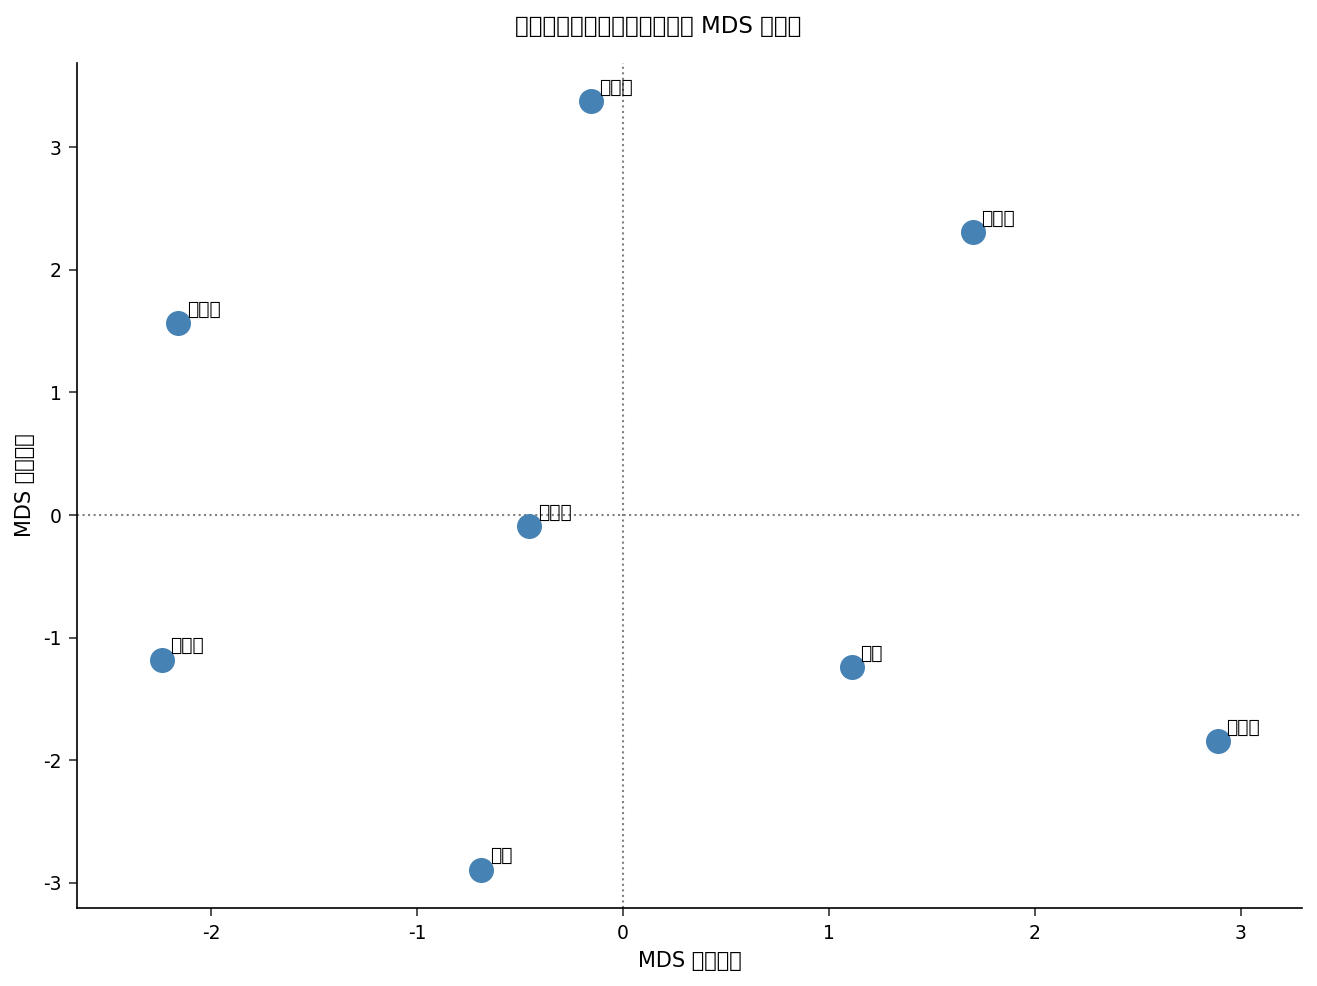

In [3]:
过程 打印 数据=mds_out 标签;
    标题 '恢复得到的 MDS 构型（对象坐标）';
运行;

过程 打印 数据=mds_fit 标签;
    标题 'MDS 拟合劣度汇总';
运行;

/* 保留构型行，并为品牌设置一个明确命名的标签列，方便 SGPLOT
   在每个点旁打印。 */
数据 mds_config;
    设置 mds_out;
    条件 _TYPE_ = 'CONFIG';
    长度 Brand $ 18;
    Brand = _NAME_;
    保留 Brand DIM1 DIM2;
运行;

/* 根据恢复出的坐标绘制感知地图，为每个标记点标注运营商名称。 */
过程 SGPLOT 数据=mds_config;
    SCATTER x=DIM1 y=DIM2 / DATALABEL=Brand
            MARKERATTRS=(SYMBOL=circlefilled size=11 color=steelblue)
            datalabelattrs=(size=9);
    REFLINE 0 / AXIS=x LINEATTRS=(pattern=dot color=gray);
    REFLINE 0 / AXIS=y LINEATTRS=(pattern=dot color=gray);
    XAXIS 标签='MDS 第一维度';
    YAXIS 标签='MDS 第二维度';
    标题 '移动运营商感知地图（恢复的 MDS 构型）';
运行;

## 步骤 4 — 对感知替代品排名

品牌团队的一个实用产出是：对每家运营商，找出其被感知为*最相似*的竞争对手（最小的非对角线差异度）。我们将矩阵重塑为长表格式，并为每家运营商提取其最近邻——这些配对就是最接近的替代品，也是最尖锐的竞争威胁。

In [4]:
数据 dissim_long;
    设置 carrier_dissim;
    长度 OTHER $ 18;
    数组 d[8] D1-D8;
    循环 j = 1 到 8;
        如果 j=1 那么 OTHER = "北极星";
        否则 如果 j=2 那么 OTHER = "蓝峰";
        否则 如果 j=3 那么 OTHER = "顶点";
        否则 如果 j=4 那么 OTHER = "都市通";
        否则 如果 j=5 那么 OTHER = "优值通";
        否则 如果 j=6 那么 OTHER = "省钱通";
        否则 如果 j=7 那么 OTHER = "中线通";
        否则 OTHER = "分毫通";
        Dissimilarity = d[j];
        如果 Carrier ne OTHER 那么 输出;
    结束;
    保留 Carrier OTHER Dissimilarity;
运行;

过程 排序 数据=dissim_long;
    按照 Carrier Dissimilarity;
运行;

数据 nearest;
    设置 dissim_long;
    按照 Carrier Dissimilarity;
    如果 first.Carrier;
运行;

过程 打印 数据=nearest noobs 标签;
    标签 OTHER = '最接近的感知替代品'
          Dissimilarity = '差异度';
    标题 '各运营商及其最接近的感知替代品';
运行;

                                                    各运营商及其最接近的感知替代品                                                     

  Carrier                    最接近的感知替代品        差异度
中线通        都市通                                1.9
优值通        省钱通                                1.8
分毫通        都市通                                  2
北极星        顶点                                 1.6
省钱通        优值通                                1.8
蓝峰         中线通                                  2
都市通        顶点                                 1.7
顶点         北极星                                1.6




NOTE: DATA dissim_long


NOTE: Read 8 rows from carrier_dissim.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=dissim_long

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 56 rows from dissim_long.
NOTE: Wrote dissim_long (56 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA nearest


NOTE: Read 56 rows from dissim_long.
NOTE: Wrote nearest (8 rows, 3 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=nearest

NOTE: PROC PRINT completed: 8 observations printed, 3 variables


## 结果解读

由于我们是从一个真正的二维潜在结构（网络质量与价格/性价比，被构造为独立变化）加上适度的调查噪声生成的差异度，`PROC MDS` 恢复出了一个干净的二维构型。拟合劣度指标稳定在约 1.85 附近——这一紧密拟合证实两个维度几乎解释了全部感知结构。

解读恢复出的地图（坐标轴只能在旋转、镜像和缩放的意义下被识别，因此我们解读方向而非绝对符号）：

- **一条轴对应网络质量** - 它将高端全国性品牌（北极星、顶点、蓝峰）与廉价 MVNO（省钱通、分毫通、优值通）区分开来，都市通与中线通位于中间。
- **另一条轴对应价格/性价比** - 它将激进的高性价比定位与高端定价定位区分开来，这也是为什么像蓝峰这样质量同样很高的品牌，会与同样高质量的北极星相距甚远：它们共享网络声誉，但在完全不同的价格故事上竞争。
- 地图没有显示单一的主导梯度：品牌分散在全部四个象限中，因此竞争格局确实是二维的，而不是单一的从高端到廉价的一条线。

**最近替代品表**将地图转化为一份行动清单。每家运营商感知上最接近的对手就是地图上与之相邻的品牌——北极星与顶点锚定了高端角落，优值通与省钱通在性价比角落配对，而都市通因为处于地图中心，成为多个中端品牌共同的最接近替代品。紧密的配对标示出正面竞争的对手；集群之间的空白区域则突显出挑战者品牌可以瞄准的、尚未被占据的定位。